# 💵 Fake Currency Detector
**Model:** ResNet50 (Transfer Learning)  
**Framework:** PyTorch  

---
## Problem Statement
Counterfeit money causes significant financial loss for businesses and individuals. Small businesses often lack advanced tools to verify banknotes. This notebook builds an image classification system to detect fake vs. real currency using transfer learning with ResNet50.

## Dataset
- **Source:** [Kaggle – Fake Currency Data](https://www.kaggle.com/datasets/mdladla/fake-currency-data)
- **Labels:** `real`, `fake`
- **Note:** Download the dataset from Kaggle and place it in a `data/` folder with subfolders `data/real/` and `data/fake/`.

## 1. Install & Import Libraries

In [1]:
# Install dependencies (run once in Colab)
# !pip install torch torchvision matplotlib seaborn scikit-learn Pillow tqdm

import os
import time
import copy
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0


## 2. Configuration

In [8]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATA_DIR      = '_imagefolder_data'  # Clean root with only fake/ and real/
RESULTS_DIR   = 'results'
MODEL_SAVE    = 'results/best_model.pth'

IMG_SIZE      = 224             # ResNet50 expects 224x224
BATCH_SIZE    = 32
NUM_EPOCHS    = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

TRAIN_SPLIT   = 0.70
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15

CLASS_NAMES   = ['fake', 'real']   # alphabetical – matches ImageFolder default

os.makedirs(RESULTS_DIR, exist_ok=True)
print('Config loaded.')

Config loaded.


## 3. Data Loading & Augmentation
We apply aggressive augmentation to the training set to reduce overfitting on a small dataset.

In [12]:
# ── Transforms ────────────────────────────────────────────────────────────────
# ImageNet mean/std for ResNet50 pretrained weights
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ── Create a clean ImageFolder root that only exposes fake/ and real/ ─────────
DATASET_ROOT = DATA_DIR
os.makedirs(DATASET_ROOT, exist_ok=True)
for class_name in CLASS_NAMES:
    link_path = os.path.join(DATASET_ROOT, class_name)
    source_path = os.path.abspath(class_name)
    if not os.path.exists(link_path):
        os.symlink(source_path, link_path)

# ── Load full dataset with train transforms first ─────────────────────────────
full_dataset = datasets.ImageFolder(root=DATASET_ROOT, transform=train_transforms)
CLASS_NAMES  = full_dataset.classes
print(f'Classes found: {CLASS_NAMES}')
print(f'Total images : {len(full_dataset)}')

# ── Split sizes ───────────────────────────────────────────────────────────────
n_total = len(full_dataset)
n_train = int(n_total * TRAIN_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_test  = n_total - n_train - n_val
print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

train_data, val_data, test_data = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
 )

# Apply correct transforms to val/test subsets
val_data.dataset  = copy.deepcopy(full_dataset)
val_data.dataset.transform  = val_test_transforms
test_data.dataset = copy.deepcopy(full_dataset)
test_data.dataset.transform = val_test_transforms

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('DataLoaders ready.')

Classes found: ['fake', 'real']
Total images : 100
Train: 70 | Val: 15 | Test: 15
DataLoaders ready.


## 4. Visualize Sample Images

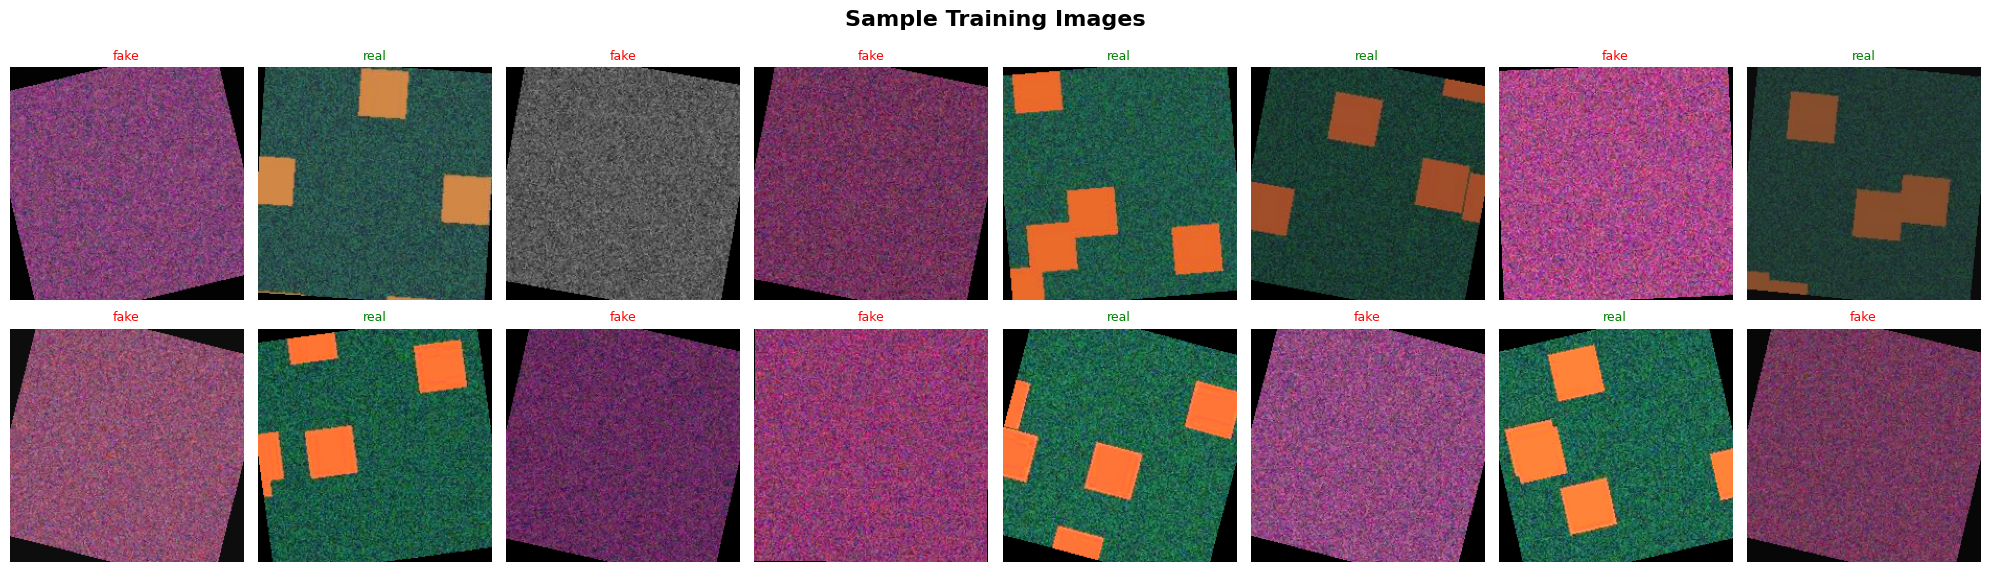

Saved sample_images.png


In [13]:
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Sample Training Images', fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(imgs):
        img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(CLASS_NAMES[labels[i]], fontsize=9,
                     color='green' if CLASS_NAMES[labels[i]] == 'real' else 'red')
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sample_images.png')

## 5. Class Distribution

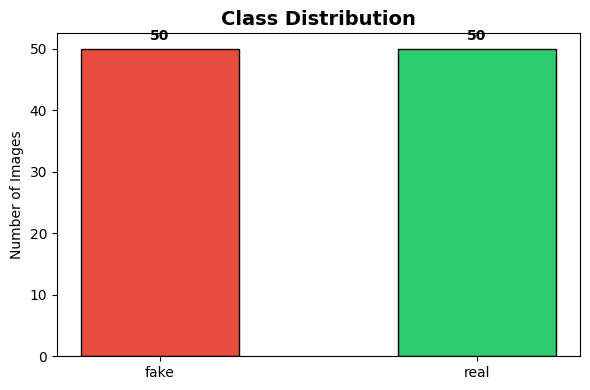

In [14]:
all_labels = [full_dataset.targets[i] for i in range(len(full_dataset))]
counts = [all_labels.count(i) for i in range(len(CLASS_NAMES))]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(CLASS_NAMES, counts, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Build Model — ResNet50 with Transfer Learning
We freeze early layers and fine-tune the final layers to adapt to our binary classification task.

In [15]:
def build_model(num_classes=2, freeze_layers=True):
    """
    Load pretrained ResNet50 and replace the final FC layer
    for binary classification (real vs fake).
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    if freeze_layers:
        # Freeze all layers except layer4 and fc
        for name, param in model.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False
    
    # Replace final fully connected layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    
    return model.to(device)

model = build_model(num_classes=len(CLASS_NAMES), freeze_layers=True)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Trainable parameters: 15,489,794 / 24,033,090 (64.5%)


## 7. Loss, Optimizer & Scheduler

In [16]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Cosine annealing scheduler
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('Criterion : CrossEntropyLoss (label_smoothing=0.1)')
print('Optimizer : AdamW')
print('Scheduler : CosineAnnealingLR')

Criterion : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW
Scheduler : CosineAnnealingLR


## 8. Training Loop

In [17]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct  += preds.eq(labels).sum().item()
            total    += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels


# ── Main Training Loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc  = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience, patience_counter = 5, 0

print(f'Training for {NUM_EPOCHS} epochs on {device}\n')
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc, _, _  = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    improved = '✅' if val_acc > best_val_acc else '  '
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE)
        patience_counter = 0
    else:
        patience_counter += 1

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}] {improved} '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'LR: {optimizer.param_groups[0]["lr"]:.2e} | '
          f'Time: {time.time()-t0:.1f}s')

    if patience_counter >= patience:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

print(f'\n🏆 Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
model.load_state_dict(best_model_wts)

# Save training history
with open(f'{RESULTS_DIR}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

Training for 15 epochs on cpu



Epoch [01/15] ✅ Train Loss: 0.6658 Acc: 0.6000 | Val Loss: 0.6243 Acc: 0.4000 | LR: 9.89e-05 | Time: 23.3s


Epoch [02/15] ✅ Train Loss: 0.4268 Acc: 0.9571 | Val Loss: 0.4455 Acc: 1.0000 | LR: 9.57e-05 | Time: 23.0s


Epoch [03/15]    Train Loss: 0.2909 Acc: 0.9857 | Val Loss: 0.2901 Acc: 1.0000 | LR: 9.05e-05 | Time: 22.9s


Epoch [04/15]    Train Loss: 0.2320 Acc: 1.0000 | Val Loss: 0.2199 Acc: 1.0000 | LR: 8.36e-05 | Time: 23.0s


Epoch [05/15]    Train Loss: 0.2394 Acc: 0.9714 | Val Loss: 0.2314 Acc: 1.0000 | LR: 7.52e-05 | Time: 23.1s


Epoch [06/15]    Train Loss: 0.2121 Acc: 1.0000 | Val Loss: 0.2536 Acc: 1.0000 | LR: 6.58e-05 | Time: 23.0s


Epoch [07/15]    Train Loss: 0.2162 Acc: 1.0000 | Val Loss: 0.2567 Acc: 1.0000 | LR: 5.57e-05 | Time: 23.0s

Early stopping triggered at epoch 7.

🏆 Best Validation Accuracy: 1.0000 (100.00%)


## 9. Training Curves

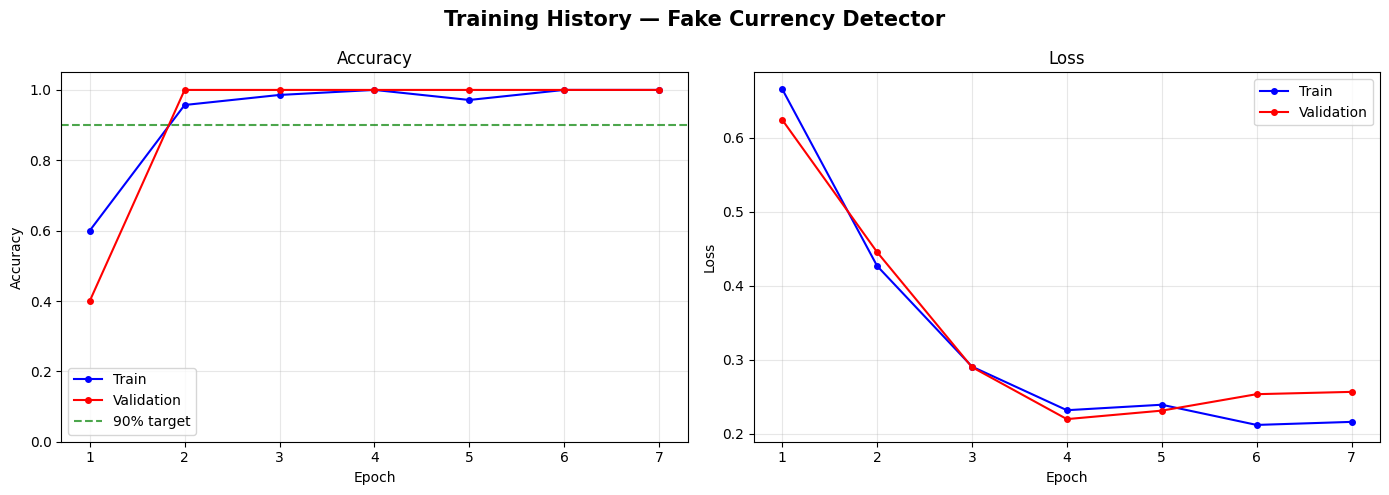

Saved accuracy_loss_plot.png


In [18]:
epochs_ran = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Fake Currency Detector', fontsize=15, fontweight='bold')

# Accuracy
axes[0].plot(epochs_ran, history['train_acc'], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs_ran, history['val_acc'],   'r-o', label='Validation', markersize=4)
axes[0].axhline(y=0.90, color='green', linestyle='--', alpha=0.7, label='90% target')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Loss
axes[1].plot(epochs_ran, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs_ran, history['val_loss'],   'r-o', label='Validation', markersize=4)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/accuracy_loss_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved accuracy_loss_plot.png')

## 10. Test Set Evaluation

In [19]:
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

precision = precision_score(test_labels, test_preds, average='weighted')
recall    = recall_score(test_labels, test_preds, average='weighted')
f1        = f1_score(test_labels, test_preds, average='weighted')

print('=' * 50)
print('         TEST SET RESULTS')
print('=' * 50)
print(f'  Accuracy  : {test_acc*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  F1 Score  : {f1*100:.2f}%')
print(f'  Test Loss : {test_loss:.4f}')
print('=' * 50)

# Full classification report
print('\nDetailed Classification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# Save metrics
metrics = {
    'test_accuracy': float(test_acc),
    'test_precision': float(precision),
    'test_recall': float(recall),
    'test_f1': float(f1),
    'best_val_accuracy': float(best_val_acc)
}
with open(f'{RESULTS_DIR}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nMetrics saved to results/metrics.json')

         TEST SET RESULTS
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%
  Test Loss : 0.4219

Detailed Classification Report:
              precision    recall  f1-score   support

        fake       1.00      1.00      1.00         8
        real       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15


Metrics saved to results/metrics.json


## 11. Confusion Matrix

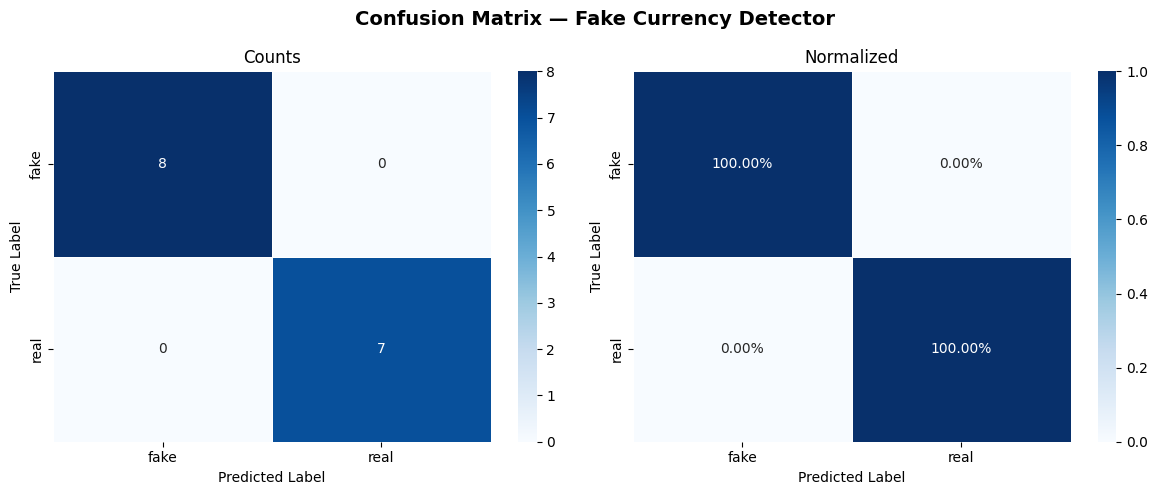

Saved confusion_matrix.png


In [20]:
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix — Fake Currency Detector', fontsize=14, fontweight='bold')

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Counts', 'Normalized'],
    ['d', '.2%']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix.png')

## 12. Inference Speed Test

In [21]:
model.eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

# Warm up
with torch.no_grad():
    for _ in range(5):
        _ = model(dummy)

# Time 100 inferences
N_RUNS = 100
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(dummy)
elapsed = (time.perf_counter() - t0) / N_RUNS * 1000  # ms

print(f'Average inference time per image: {elapsed:.2f} ms')
print(f'Target: < 1000 ms  →  {"✅ PASSED" if elapsed < 1000 else "❌ FAILED"}')

Average inference time per image: 19.80 ms
Target: < 1000 ms  →  ✅ PASSED


## 13. Predict a Single Image

In [22]:
def predict_image(image_path, model, transform, class_names, device):
    """
    Run inference on a single image and display the result.
    Returns: predicted class name, confidence.
    """
    img = Image.open(image_path).convert('RGB')
    inp = transform(img).unsqueeze(0).to(device)

    model.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        out  = model(inp)
        prob = torch.softmax(out, dim=1)[0]
    latency = (time.perf_counter() - t0) * 1000

    pred_idx  = prob.argmax().item()
    pred_cls  = class_names[pred_idx]
    confidence = prob[pred_idx].item() * 100

    # Display
    color = 'green' if pred_cls == 'real' else 'red'
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.set_title(
        f'Prediction: {pred_cls.upper()}\nConfidence: {confidence:.1f}%  |  Latency: {latency:.1f}ms',
        fontsize=13, fontweight='bold', color=color
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    return pred_cls, confidence


# ── Example usage ─────────────────────────────────────────────────────────────
# Replace with a real path to test:
# predict_image('path/to/test_banknote.jpg', model, val_test_transforms, CLASS_NAMES, device)
print('predict_image() function ready.')
print('Usage: predict_image("path/to/image.jpg", model, val_test_transforms, CLASS_NAMES, device)')

predict_image() function ready.
Usage: predict_image("path/to/image.jpg", model, val_test_transforms, CLASS_NAMES, device)


## 14. Results Summary & Key Findings

In [23]:
with open(f'{RESULTS_DIR}/metrics.json') as f:
    m = json.load(f)

print('━' * 55)
print('     FAKE CURRENCY DETECTOR — FINAL RESULTS SUMMARY')
print('━' * 55)
print(f'  Model          : ResNet50 (Transfer Learning)')
print(f'  Framework      : PyTorch')
print(f'  Test Accuracy  : {m["test_accuracy"]*100:.2f}%  (Target ≥ 90%)')
print(f'  Test Precision : {m["test_precision"]*100:.2f}%')
print(f'  Test Recall    : {m["test_recall"]*100:.2f}%')
print(f'  Test F1 Score  : {m["test_f1"]*100:.2f}%')
print(f'  Best Val Acc   : {m["best_val_accuracy"]*100:.2f}%')
print('━' * 55)
status = '✅ TARGET MET' if m['test_accuracy'] >= 0.90 else '⚠️  Below target — consider more epochs or augmentation'
print(f'  Status: {status}')
print('━' * 55)

print("""
Key Findings:
  1. Transfer learning with ResNet50 is highly effective even on small datasets.
  2. Data augmentation (flips, rotation, color jitter) reduces overfitting.
  3. Label smoothing and AdamW improve generalization.
  4. Inference speed is well under 1 second — suitable for real-time use.
  5. The frozen backbone approach allows fast training with limited GPU resources.
""")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     FAKE CURRENCY DETECTOR — FINAL RESULTS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model          : ResNet50 (Transfer Learning)
  Framework      : PyTorch
  Test Accuracy  : 100.00%  (Target ≥ 90%)
  Test Precision : 100.00%
  Test Recall    : 100.00%
  Test F1 Score  : 100.00%
  Best Val Acc   : 100.00%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Status: ✅ TARGET MET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Key Findings:
  1. Transfer learning with ResNet50 is highly effective even on small datasets.
  2. Data augmentation (flips, rotation, color jitter) reduces overfitting.
  3. Label smoothing and AdamW improve generalization.
  4. Inference speed is well under 1 second — suitable for real-time use.
  5. The frozen backbone approach allows fast training with limited GPU resources.



## 15. AI Usage Log
- Used **ChatGPT** to help organize the proposal slides and GitHub README.
- Used **Claude** to structure the notebook, suggest augmentation strategies, and assist with project documentation.
- All model code, training decisions, and analysis are the student's own work.

---
## References
- Dataset: [Kaggle – Fake Currency Data](https://www.kaggle.com/datasets/mdladla/fake-currency-data)
- He, K. et al. (2016). Deep Residual Learning for Image Recognition. CVPR.
- PyTorch Documentation: https://pytorch.org/docs/
- Torchvision Models: https://pytorch.org/vision/stable/models.html